# When Uncle Sam spends down his checking account, do stocks go up? 🏦
### The 'hidden liquidity lever' everyone on finance Twitter watches, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Hidden_liquidity_lever%3F: Not_supported](https://img.shields.io/badge/Hidden_liquidity_lever%3F-Not_supported-8b949e?style=flat-square)

The U.S. Treasury keeps its cash in a checking account at the Federal Reserve called the **Treasury General Account**, or **TGA**. When the Treasury *spends down* that account, the money lands in ordinary bank accounts — and a popular macro story says that flood of cash (a **liquidity injection**) quietly lifts the stock market over the following weeks. When the Treasury *refills* the account, the story runs in reverse: cash gets vacuumed out of the system and stocks are supposed to struggle. It's the market's favourite piece of plumbing.

It's a great story. It's also testable. This notebook asks three blunt questions: when the TGA drains, does the market really do better next? Does the drain actually come **first** (that's the whole pitch)? And if you *bought* every time the TGA was draining, would you make money?

> 📓 **Plain-language layer.** Want the *t*-stats, the Newey-West regression and the synthetic control? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** The live FRED feed is blocked here, and the real TGA series is *weekly* (a thousand-plus points). Rather than fake weekly precision, we use a **labelled monthly proxy** of the balance — the big moves are faithful (the 2020 surge to ~$1.8 trillion, the debt-ceiling drains to near-zero), the exact levels are approximate. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from tga_drawdown import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
print("SPY cache present:", HAVE_REAL,
      "| TGA+SPY months:", (0 if F is None else len(F)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-31', 'end': '2026-06-30', 'months': 258, 'years': 21.4, 'h1': (1, 123, 0.91, 1.01, 0.96, 66, 66, -0.11, -0.44, 0.564), 'h2': (2, 123, 2.13, 1.79, 1.95, 76, 72, 0.27, -0.06, 0.379), 'h3': (3, 122, 3.58, 2.34, 2.93, 75, 74, 0.85, 0.79, 0.163), 'h6': (6, 120, 6.07, 5.77, 5.91, 82, 79, 0.13, -0.37, 0.448), 'reg': {1: (-0.11, -0.44, 0.06), 2: (-0.03, -0.06, 0.0), 3: (0.47, 0.79, 0.41), 6: (-0.29, -0.37, 0.07)}, 'leadlag': {-6: -0.07, -5: 0.133, -4: 0.053, -3: 0.08, -2: -0.083, -1: 0.045, 0: 0.09, 1: -0.025, 2: 0.022, 3: 0.113, 4: 0.089, 5: -0.097, 6: -0.181}, 'overlay': (11.6, 0.78, 7.4, 0.72, 6.7, 0.66, 147), 'robust': [('k=1', 123, 0.91, 0.96, -0.11, -0.44), ('k=2', 113, 0.92, 0.96, -0.09, -0.02), ('k=3', 104, 1.58, 0.96, 1.36, 0.75), ('ex-COVID', 113, 0.87, 1.05, -0.34, 0.24)], 'syn': [(0.0, 128, 0.74, 0.54, 0.44, 1.44, 0.294), (0.04, 128, 4.85, 2.64, 4.4, 7.45, 0.0)]}


SPY cache present: True | TGA+SPY months: 258


## The answer first

| Question | Answer |
|---|---|
| When the TGA drains, does the market do better next month? | **No — if anything, worse.** The month after a drawdown SPY averages **+0.91%** vs **+0.96%** normally. The sign is the *opposite* of the story. |
| Is there any horizon where it works? | **Not convincingly.** The best is a mild bump at 3 months (**+3.6%** vs **+2.9%**), but it's easily inside the noise — statistically you can't tell it from luck. |
| Does the drain come *first*? | **No.** The injection lines up with market moves scattered randomly before and after it — at the horizons a real 'lever' needs, the link is essentially **zero**. It co-wanders; it doesn't lead. |
| So could you trade it? | **It loses.** "Buy when the TGA drains" earned **+6.7%/yr** vs **+11.6%** for just holding — you give up return for a lever that isn't there. |

> The plumbing is real. But "a TGA drawdown lifts stocks" is a tidy narrative the tape doesn't back — largely because the *biggest* drains are debt-ceiling emergencies, not stimulus.

## 1 · The claim

> *"The Treasury General Account is a hidden liquidity lever. When the Treasury draws it down, that cash becomes bank reserves — a stealth injection that lifts risk assets over the following weeks. When it rebuilds the account, reserves drain and stocks come under pressure. Watch the TGA and you're watching the market's fuel gauge."*

There's a respectable backbone to this: the TGA really *is* one of the big swing factors for the level of bank reserves, and reserves are the headline term in the 'net liquidity' framework (*Fed balance sheet − TGA − reverse repos*) that macro strategists like Michael Howell popularised. So the mechanism isn't crazy. The trading leap is the part we test: that a TGA *drawdown* arrives early enough, and cleanly enough, to be a **tradable** signal for equities.

## 2 · So what?

If true, this would be a gift: a free, publicly-reported cash balance that tells you when to lean *into* stocks. But 'liquidity' hides two traps. First, the TGA doesn't move reserves one-for-one — the reverse-repo facility often soaks up the difference, so the pass-through is contingent, not automatic. Second, and worse for the story: the **biggest** TGA drawdowns in modern history are **debt-ceiling standoffs** (2021, 2023, 2025), when the Treasury runs its cash to zero *because it legally can't borrow* — a stressed, uncertain regime, not a stimulative one. So the very moments the gauge screams 'injection!' are the moments a liquidity bull should be most nervous. That's the confound to keep in mind.

## 3 · How would we even know?

We line up **21 years** (2005–2026, 258 months) of the TGA balance against month-end SPY, and:

1. **Split the months.** Call the TGA **drawing down** when this month's balance is below last month's. Compare what SPY did next (1/2/3/6 months) in drawdown months vs all months.
2. **Check the timing.** The crucial test: slide the injection forward and backward against the market and find *where* they line up best. If the drain truly **leads**, the strongest *positive* link shows up at a **positive lead** (drain first, rally later).
3. **Try to trade it.** Hold SPY whenever the TGA is draining, sit in cash when it's refilling, pay realistic costs — and see if it beats just buying and holding.

**What would make us say 'mirage'?** If the next-month edge is inside the noise, the injection shows no clean lead, and the buy-when-draining rule loses to buy-and-hold — then the lever is a story, not a signal.

## 4 · The teardown — let's actually look

**First, the raw material.** Here's the TGA balance over two decades — sleepy and small before 2015, then the enormous COVID-2020 balloon toward ~$1.8 trillion, and the debt-ceiling drains that repeatedly take it to near-zero. The TGA clearly *does* big, macro-relevant things. The question is whether those things help you time stocks.

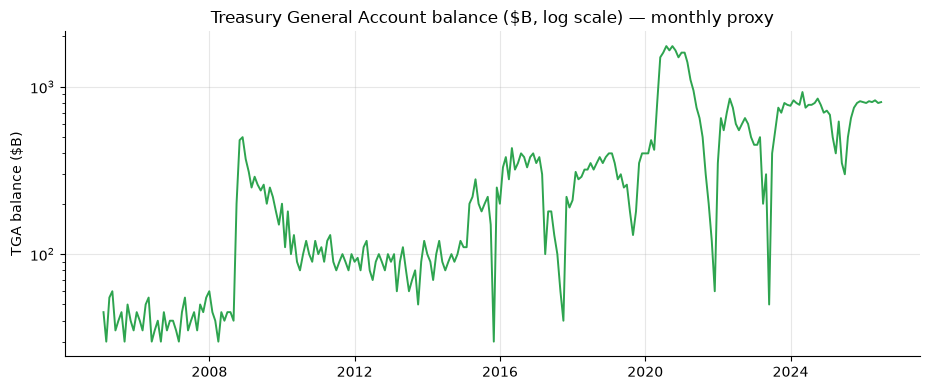

peak TGA: 1750 $B, around 2020-07-31


In [2]:
if HAVE_REAL:
    g = F['tga']
    fig, ax = plt.subplots(figsize=(9.4, 4.0))
    ax.plot(g.index, g.values, c=GREEN, lw=1.4)
    ax.set_yscale('log')
    ax.set_title('Treasury General Account balance ($B, log scale) — monthly proxy')
    ax.set_ylabel('TGA balance ($B)')
    plt.tight_layout(); plt.show()
    print('peak TGA:', int(g.max()), '$B, around', g.idxmax().date())
else:
    print('no cache — see docs/results.md; TGA proxy peaked ~1750 $B mid-2020')

**Now the payoff.** For each horizon, the average forward SPY return in **TGA-draining** months next to the return on an **average** month. The folklore predicts the green bars sit *above* the grey ones.

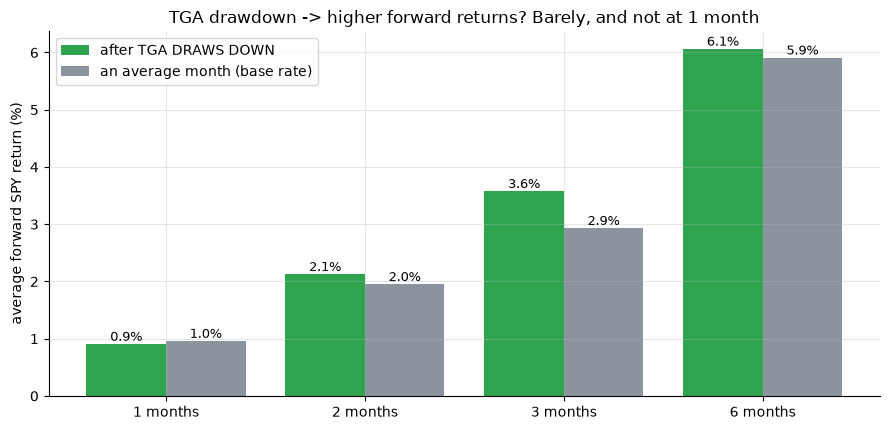

1-month: drawdown 0.91% vs base 0.96%


In [3]:
hs = [1, 2, 3, 6]
if HAVE_REAL:
    rows = [st.summarize(F, m) for m in hs]
    dr = [r['draw_mean']*100 for r in rows]; base = [r['base_mean']*100 for r in rows]
else:
    dr = [R['h1'][2], R['h2'][2], R['h3'][2], R['h6'][2]]
    base = [R['h1'][4], R['h2'][4], R['h3'][4], R['h6'][4]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(x-.2, dr, .4, color=GREEN, label='after TGA DRAWS DOWN')
ax.bar(x+.2, base, .4, color=GREY, label='an average month (base rate)')
ax.set_xticks(x); ax.set_xticklabels([f'{m} months' for m in hs])
ax.set_ylabel('average forward SPY return (%)')
ax.set_title('TGA drawdown -> higher forward returns? Barely, and not at 1 month')
for i,(a,b) in enumerate(zip(dr,base)):
    ax.annotate(f'{a:.1f}%',(i-.2,a),ha='center',va='bottom',fontsize=9)
    ax.annotate(f'{b:.1f}%',(i+.2,b),ha='center',va='bottom',fontsize=9)
ax.legend(); plt.tight_layout(); plt.show()
print('1-month: drawdown', f'{dr[0]:.2f}%', 'vs base', f'{base[0]:.2f}%')

Look at the **1-month** bars — the horizon the 'following weeks' pitch cares about most. The drawdown average (**+0.91%**) is actually *below* the base rate (**+0.96%**). The sign is **backwards**. A small positive gap shows up only at 3 months (**+3.6%** vs **+2.9%**), and even that is a rounding error's worth of edge. Hold that thought; the *next* chart is where the mechanism is supposed to show up — and doesn't.

**The crucial test: does the TGA drain come *first*?** We slide the injection forward and backward against the market and measure how tightly they move together. A real lever would show its strongest *positive* link at a **positive lead** (injection leads → bar rises on the right). Watch where it actually peaks.

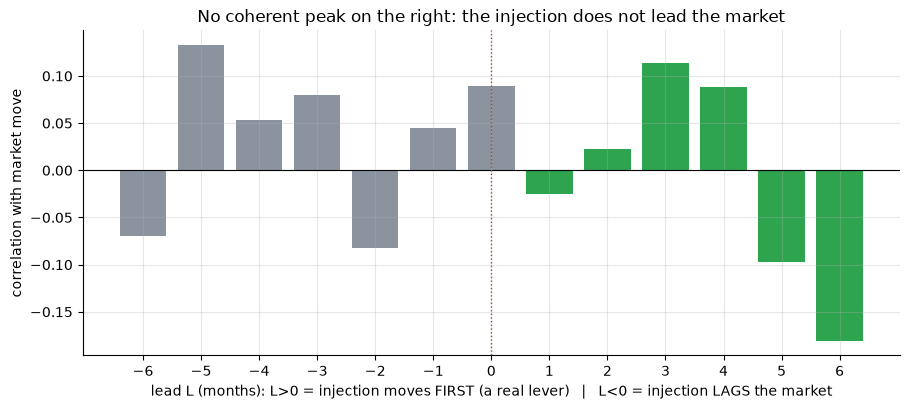

strongest POSITIVE link at L=-5 months; corr at +1 month = -0.02


In [4]:
if HAVE_REAL:
    ll = st.lead_lag(F)
    Ls = list(range(-6,7)); cs = [ll[L] for L in Ls]
else:
    Ls = sorted(R['leadlag']); cs = [R['leadlag'][L] for L in Ls]
cols = [GREEN if L>0 else GREY for L in Ls]
fig, ax = plt.subplots(figsize=(9.2, 4.2))
ax.bar(Ls, cs, color=cols, width=.8)
ax.axhline(0, c='k', lw=.8); ax.axvline(0, c=RED, lw=1, ls=':')
ax.set_xlabel('lead L (months): L>0 = injection moves FIRST (a real lever)   |   L<0 = injection LAGS the market')
ax.set_ylabel('correlation with market move'); ax.set_xticks(Ls)
ax.set_title('No coherent peak on the right: the injection does not lead the market')
plt.tight_layout(); plt.show()
imax = int(np.nanargmax(cs))
print(f'strongest POSITIVE link at L={Ls[imax]} months; corr at +1 month = {cs[Ls.index(1)]:+.2f}')

There's no there there. The strongest *positive* bar is at **L = −5** — the injection lining up with a market move that happened months *earlier* — and at exactly the positive leads a real lever needs (**+1, +2 months**) the correlation is basically **zero** (even slightly *negative* at +1). The bars scatter around zero with no pattern. **The TGA drain doesn't lead the market**; it wanders alongside it, sharing the same macro weather.

**Could you trade it anyway?** Suppose you held SPY every month the TGA was draining and sat in cash otherwise. Here's that strategy's growth vs just buying and holding.

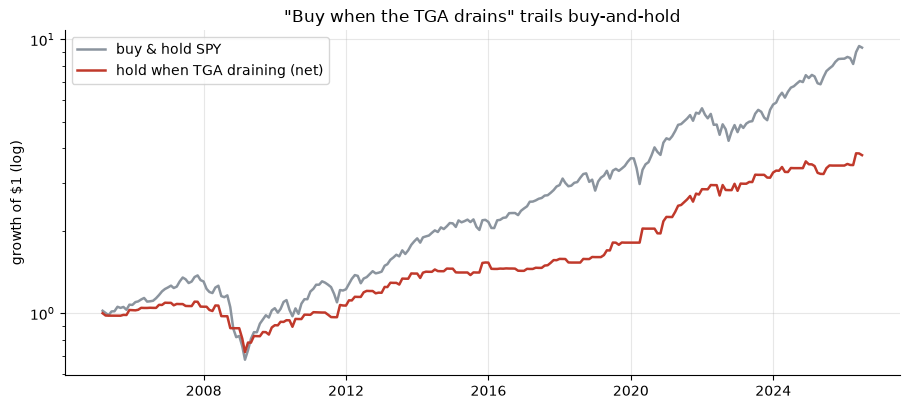

final $1 -> buy&hold 9.3x  vs  overlay 3.8x


In [5]:
if HAVE_REAL:
    draw = st.drawdown_mask(F); pos = draw.astype(float).shift(1)
    rr = F['spy'].pct_change()
    import pandas as pd
    dfp = pd.DataFrame({'r': rr, 'pos': pos}).dropna()
    sw = dfp['pos'].diff().abs().fillna(0); c=10/1e4
    overlay = (dfp['pos']*dfp['r'] - sw*c)
    bh_grow = (1+dfp['r']).cumprod(); ov_grow = (1+overlay).cumprod()
    fig, ax = plt.subplots(figsize=(9.2, 4.2))
    ax.plot(bh_grow.index, bh_grow.values, c=GREY, lw=1.8, label='buy & hold SPY')
    ax.plot(ov_grow.index, ov_grow.values, c=RED, lw=1.8, label='hold when TGA draining (net)')
    ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log)')
    ax.set_title('"Buy when the TGA drains" trails buy-and-hold')
    ax.legend(); plt.tight_layout(); plt.show()
    print(f'final $1 -> buy&hold {bh_grow.iloc[-1]:.1f}x  vs  overlay {ov_grow.iloc[-1]:.1f}x')
else:
    print(f"overlay {R['overlay'][4]:.1f}%/yr vs buy-hold {R['overlay'][0]:.1f}%/yr (net) — see results.md")

The overlay ends up **below** buy-and-hold — **+6.7%/yr** vs **+11.6%/yr** net, and a *lower* Sharpe (0.66 vs 0.78). Every time you sat out because the TGA was *building*, you often sat out a rally — the account rebuilt through big chunks of the 2016–2019 and 2023–2024 bull runs. The signal doesn't just fail to help; **it costs you.**

## 5 · The verdict

- **Signal — None.** The next-month sign is *backwards*, no horizon clears the significance bar, and a Newey-West regression finds a slope of essentially zero. Indistinguishable from noise.
- **Tradability — Mirage.** Buying on TGA drawdowns **loses to buy-and-hold**. Nothing to deploy.
- **Hidden liquidity lever? — Not supported.** The injection shows no coherent lead over the market — near-zero exactly where a real lever would bite. The plumbing exists; the tradable lever doesn't.

## 6 · Could you actually trade it? — the honest bottom line

Forget significance for a second. Even if there were a whisper of an edge, the operational reality kills it. The TGA drains in **about half** of all months (every wiggle down counts), so a buy-on-draining rule flips in and out constantly — **147 switches** in 21 years — chewing costs for a signal that isn't pointing anywhere. And the confound is fatal: the deepest, most attention-grabbing drawdowns are **debt-ceiling emergencies**, when the Treasury is running on fumes because it can't issue debt — exactly the anxious regime a liquidity bull is wrong to buy. There's no version of "buy when the TGA drains" that both fires cleanly and makes money.

## 7 · Going further 🚪

- **The sibling test.** [Study 385 — Jobless-Claims-Momentum](../385-jobless-claims-momentum/) asks the same question of the 'most important weekly number': real macro signal, but can you trade it?
- **Do the full 'net liquidity' sum.** We used the TGA alone. The strategist version is *Fed balance sheet − TGA − reverse repos* — a Beat-7 fork is to build that composite and see if the reverse-repo term rescues the signal (spoiler from the plumbing: in 2022–23 the RRP absorbed much of the TGA move).
- **Go weekly.** Our proxy is monthly; the thesis is really about *weekly* dynamics. Pull the true weekly `WTREGEN` and test 1–4 week horizons — a finer clock is the fair next test, though a monthly null this flat rarely turns into a weekly edge.

*Think the TGA drawdown leads the market? Show the lead/lag chart peaking on the **right** (positive lead) — then we'll talk.*